# Complexity-Guided Pre-Pretraining: 670M-scale C4 transfer

Analysis of the final lab run reported in `logs/README.md` (entry *2026-07-23*). The experiment asks a simple question: **if you pretrain a language model on a synthetic, rule-generated pattern before showing it any real text, does that "warm-up" help once it moves on to real text?**

**Two phases per condition.**

1. **Phase 1 (pre-pretraining)** — train a 670M Llama from scratch on one pattern (a synthetic sequence such as Dyck brackets or copying, or a natural corpus such as C4 itself).
2. **Phase 2 (pretraining)** — reset all the weights (except the attention layers) and reseize the embeddings, continue training on 5.2B tokens of C4, then evaluate on held-out C4 perplexity and five standard benchmarks (ARC-Easy, BLiMP, HellaSwag, LAMBADA, Winogrande).

The `c4` condition (phase 1 = phase 2 = C4) is the **baseline**: a model that never saw a synthetic pattern. Every other condition is named `<pattern>_c4`, e.g. `mixer_c4` means "pre-pretrained on the mixer pattern, then pretrained on C4".

**Glossary — the four phase-1 measurements used throughout.**

| Symbol      | Name                   | Plain-language meaning                                                                                                                                          |
|-------------|------------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------|
| gzip        | gzip complexity        | compressed / original byte size of the raw text — a cheap, crude proxy for the Kolmogorov complexit    y.                                                       |
| oracle loss | oracle loss            | the *best possible* loss for a model that already knows the exact rule generating the pattern. It's a lower bound, not something a real model beats.            |
| $S_T$       | prequential epiplexity | bits/token the model *spent learning* the pattern during phase 1 — a large $S_T$ means there was a lot of learnable structure.                                  |
| $H_T$       | time-bounded entropy   | bits/token of residual uncertainty *after* the model has mostly converged — how unpredictable the pattern still is once "learned".                              |


**Questions we want answered.**

| #  | Question                                                                                                                        |
|----|---------------------------------------------------------------------------------------------------------------------------------|
| Q0 | Does the *size* of the phase-1 undertraining gap (achieved loss − oracle loss) predict how well a pattern transfers downstream? |
| Q1 | Do gzip complexity and achievable validation perplexity always correlate?                                                       |
| Q2 | Is epiplexity $S_T$ measuring something gzip does not?                                                                          |
| Q3 | Does *any* phase-1 property (gzip, $S_T$, $H_T$, structural fraction, oracle loss) predict downstream transfer?                 |
| Q4 | Does the "complexity matching" hypothesis (match the synthetic source to the target domain) hold?                               |
| Q5 | Is structural information acquired in phase 1 *conserved* in phase 2?                                                           |
| Q6 | Are the observed downstream deltas larger than the measurement noise floor?                                                     |


Everything below is single-seed. Section 4 (Q6) is devoted to establishing what that means for the strength of any claim we can make — read it before trusting any correlation in Q1, Q2, Q4, and Q5.

**A note on the figures.** ~20 conditions is too many to label on one plot without it turning into alphabet soup. Every scatter plot below therefore shows *all* conditions as small gray dots (they still count in every correlation/statistic reported), but only labels and colors a handful of **canonical examples** chosen to illustrate the point being made: `c4`/`fineweb_edu` (natural text), `random`/`identity` (sanity-check controls), `mixer` (best-performing synthetic pattern), `shuffle_dyck_16` (a structured formal language), `nca_paper` (a cellular-automaton pattern), and `periodic` (a trivial repeating pattern).

In [ ]:
from __future__ import annotations

import json
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from scipy import stats

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
while not (ROOT / "logs" / "measurements").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

LOGS = ROOT / "logs"
MEAS = LOGS / "measurements"
REPORTS = LOGS / "reports"
RUNS = LOGS / "runs"
PLOTS = LOGS / "plots" / "analysis"
PLOTS.mkdir(parents=True, exist_ok=True)

SCALE = "670m"
BASELINE = "c4"
LN2 = math.log(2)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# Cool Style for Matplotlib!
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.titleweight": "bold",
        "axes.labelsize": 9,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "legend.fontsize": 8,
        "axes.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#333333",
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "figure.autolayout": True,
    }
)

# Shared palette
FAMILY_COLORS = {
    "control": "#8C8C8C",  # random / identity: sanity checks, not real hypotheses
    "natural": "#3B75AF",  # c4, fineweb-edu, open-web-math, codeparrot
    "composite": "#EF8636",  # mixer, composite_mirror_repeat
    "dyck": "#519E3E",  # nested-bracket languages
    "nca": "#C53A32",  # neural cellular automata patterns
    "simple": "#8D6AB8",  # copy / counting / periodic / ...
    "other": "#555555",
}

# With ~20 conditions, labelling every point makes a scatter plot unreadable. Each
# figure instead highlights this fixed, small set of "canonical" conditions chosen to
# span the families above (2 natural, 2 controls, 1 composite, 1 dyck, 1 nca, 1 simple).
# All conditions still contribute to every correlation/statistic computed in the text;
# only the plotted *labels* are curated.
CANONICAL_PRE = [
    "c4",
    "fineweb_edu",
    "random",
    "identity",
    "mixer",
    "shuffle_dyck_16",
    "nca_learnable_25",
    "periodic",
]


def scatter_with_highlights(
    ax, df, xcol, ycol, name_col="name", highlight=CANONICAL_PRE, s_bg=14, s_hi=42
):
    """Scatter xcol vs ycol, labelling only rows whose name_col is in `highlight`.

    The remaining (majority of) points are drawn small and gray: they still count
    towards every correlation reported alongside the plot, they are just not labelled
    individually so the figure stays legible.
    """
    bg = df[~df[name_col].isin(highlight)]
    ax.scatter(bg[xcol], bg[ycol], s=s_bg, color="#D0D0D0", zorder=2, linewidths=0)
    hi = df[df[name_col].isin(highlight)]
    seen_fam = set()
    for _, r in hi.iterrows():
        fam = r["family"] if "family" in r and pd.notna(r["family"]) else "other"
        color = FAMILY_COLORS.get(fam, FAMILY_COLORS["other"])
        ax.scatter(
            r[xcol],
            r[ycol],
            s=s_hi,
            color=color,
            zorder=3,
            edgecolors="white",
            linewidths=0.6,
            label=fam if fam not in seen_fam else None,
        )
        seen_fam.add(fam)
        ax.annotate(
            r[name_col], (r[xcol], r[ycol]), fontsize=6.5, xytext=(4, 3), textcoords="offset points"
        )


print("repo root:", ROOT)

repo root: /home/nicholas/Documents/patterns


## 0. Load everything

Three sources are joined:

* `logs/measurements/c4_complexity.csv` — phase-1 information-theoretic metrics, one row per pattern/corpus (this is where gzip, $S_T$, $H_T$, oracle loss live).
* `logs/measurements/c4_evals.csv` — phase-2 downstream metrics, one row per model (`<pattern>_c4` or the `c4` baseline).
* `logs/reports/<run>/670m.json` + `logs/runs/<run>/670m/{training,validation}.jsonl` + `evals.yaml`   — the raw artifacts behind those two CSVs (token budgets, loss curves, per-task eval stderr), used later for the finer-grained checks in Sections 5 and 8.


In [ ]:
def _num(x):
    """Coerce a CSV cell ('12.3%', '+4.1x', 'N/A', ...) to a float, or NaN if not numeric."""
    if isinstance(x, str):
        x = x.strip()
        if x in {"N/A", "", "nan", "None"}:
            return np.nan
        x = x.replace("%", "").replace("\u00d7", "").lstrip("+")
    try:
        return float(x)
    except (TypeError, ValueError):
        return np.nan


comp = pd.read_csv(MEAS / "c4_complexity.csv").rename(columns={"Dataset/Pattern": "name"})
for c in comp.columns[1:]:
    comp[c] = comp[c].map(_num)
comp = comp.rename(
    columns={
        "Val Loss": "p1_val_loss",
        "Val PPL": "p1_val_ppl",
        "S (bits/tok)": "p1_S",
        "H (bits/tok)": "p1_H",
        "Total (b/t)": "p1_total",
        "Struct Frac": "p1_struct_frac",
        "GZip Compl.": "gzip",
        "Oracle Loss": "oracle_loss",
        "Lang Entropy": "lang_entropy",
    }
)

# Natural corpora (c4, fineweb_edu, open_web_math, codeparrot) have no known "true"
# generating process, so c4_complexity.csv leaves Oracle Loss blank for them. Lang
# Entropy — an external estimate of the corpus's entropy rate — is the closest
# available stand-in, so we use it to fill that gap. Synthetic patterns already have a
# real oracle loss and are left untouched (their lang_entropy is NaN, so fillna is a no-op).
comp["oracle_loss"] = comp["oracle_loss"].fillna(comp["lang_entropy"])


evals = pd.read_csv(MEAS / "c4_evals.csv").rename(columns={"Model": "model"})
for c in evals.columns[1:]:
    evals[c] = evals[c].map(_num)
evals = evals.rename(
    columns={
        "ARC-Easy": "arc_easy",
        "BLiMP": "blimp",
        "HellaSwag": "hellaswag",
        "LAMBADA": "lambada",
        "Winogrande": "winogrande",
        "Val Loss": "d_val_loss",
        "Val PPL": "d_val_ppl",
        "PPL Impr%": "ppl_impr_pct",
        "Speedup": "speedup",
    }
)


def load_report(run: str) -> dict | None:
    p = REPORTS / run / f"{SCALE}.json"
    return json.loads(p.read_text()) if p.exists() else None


def load_curve(run: str, kind: str = "training") -> pd.DataFrame | None:
    p = RUNS / run / SCALE / f"{kind}.jsonl"
    if not p.exists():
        return None
    recs = [json.loads(line) for line in p.read_text().splitlines() if line.strip()]
    return pd.DataFrame(recs)


def load_evals_yaml(run: str) -> dict | None:
    p = RUNS / run / SCALE / "evals.yaml"
    if not p.exists():
        return None
    return yaml.safe_load(p.read_text()).get("results", {})


FAMILY = {
    "random": "control",
    "identity": "control",
    "c4": "natural",
    "fineweb_edu": "natural",
    "open_web_math": "natural",
    "codeparrot": "natural",
    "mixer": "composite",
    "composite_mirror_repeat": "composite",
}
for n in ["shuffle_dyck_8", "shuffle_dyck_16", "shuffle_dyck_32", "shuffle_dyck_64"]:
    FAMILY[n] = "dyck"
for n in ["nca_paper", "nca_learnable_25", "nca_learnable_50"]:
    FAMILY[n] = "nca"
for n in [
    "periodic",
    "copy",
    "counting_anbn",
    "counting_anbncn",
    "interleaving",
    "permutation_cycle",
    "hierarchical",
]:
    FAMILY[n] = "simple"

comp["family"] = comp["name"].map(FAMILY).fillna("other")
comp.groupby("family")["name"].apply(list)


rows = []
for model in evals["model"]:
    is_base = model == BASELINE
    pre = None if is_base else model[: -len("_c4")]
    # The baseline (`c4`) has no separate pre-pretraining phase, but c4_complexity.csv
    # still carries a `c4` row (gzip / S_T / H_T of the C4 corpus itself). We attribute
    # that row to the baseline too, so its phase-1-style columns aren't blank below;
    # `pre` itself is still reported as "(none)" since there truly is no separate phase.
    comp_key = BASELINE if is_base else pre
    r = {"model": model, "pre": pre if pre else "(none)", "is_baseline": is_base}

    c1 = comp.loc[comp["name"] == comp_key]
    assert len(c1) == 1, f"phase-1 row missing for {comp_key}"
    r.update({k: v for k, v in c1.iloc[0].items() if k != "name"})
    if pre is not None:
        rep1 = load_report(pre)
        if rep1:
            r["p1_tokens"] = rep1.get("total_train_tokens")
            r["p1_init_loss"] = rep1.get("initial_train_loss_nats")
            r["p1_final_train_loss"] = rep1.get("final_train_loss_nats")
            r["p1_S_report"] = rep1.get("S_bits_per_train_token")

    rep2 = load_report(model)
    if rep2:
        r["p2_S"] = rep2.get("S_bits_per_train_token")
        r["p2_H"] = rep2.get("H_bits_per_test_token")
        r["p2_struct_frac"] = rep2.get("structural_fraction")
        r["p2_init_loss"] = rep2.get("initial_train_loss_nats")
        r["p2_final_train_loss"] = rep2.get("final_train_loss_nats")
        r["p2_tokens"] = rep2.get("total_train_tokens")
    rows.append(r)

M = pd.DataFrame(rows).merge(evals, on="model", how="left")
M["family"] = M["family"].fillna("natural")

base = M.loc[M["is_baseline"]].iloc[0]
M["d_loss_delta"] = M["d_val_loss"] - base["d_val_loss"]
M = M.sort_values("d_val_loss").reset_index(drop=True)

cols = [
    "model",
    "family",
    "gzip",
    "p1_S",
    "p1_H",
    "p1_struct_frac",
    "oracle_loss",
    "d_val_loss",
    "d_loss_delta",
    "ppl_impr_pct",
    "p2_S",
]
M[cols]

,model,family,gzip,p1_S,p1_H,p1_struct_frac,oracle_loss,d_val_loss,d_loss_delta,ppl_impr_pct,p2_S
0,mixer_c4,composite,0.3073,0.5739,5.2770,0.0981,0.9094,2.9045,-0.0255,2.5100,0.6007
1,shuffle_dyck_16_c4,dyck,0.6215,0.2078,3.1379,0.0621,2.0622,2.9102,-0.0198,1.9600,0.6257
2,identity_c4,control,0.0283,0.3959,0.0000,1.0000,0.0014,2.9131,-0.0169,1.6800,0.6286
3,counting_anbncn_c4,simple,0.1280,1.3962,2.7822,0.3341,0.1138,2.9132,-0.0168,1.6600,0.6227
4,shuffle_dyck_32_c4,dyck,0.7458,0.2706,3.6938,0.0683,2.4086,2.9132,-0.0168,1.6600,0.6180
5,shuffle_dyck_8_c4,dyck,0.5139,0.1579,2.6033,0.0572,1.7156,2.9144,-0.0156,1.5500,0.6453
6,permutation_cycle_c4,simple,0.0381,1.2267,3.2464,0.2743,0.0057,2.9164,-0.0136,1.3500,0.6281
7,periodic_c4,simple,0.0112,0.5804,3.6025,0.1388,0.0057,2.9164,-0.0136,1.3500,0.6293
8,counting_anbn_c4,simple,0.1210,1.4886,2.0311,0.4229,0.1669,2.9172,-0.0128,1.2800,0.6290
9,interleaving_c4,simple,0.0302,1.7004,2.1210,0.4450,0.0027,2.9173,-0.0127,1.2600,0.6295


### 0.a Phase-1 compute is not held constant across conditions — and is deliberately capped short of convergence

Phase-1 training length differs by pattern family:

* roughly 30M tokens for Dyck languages and all simple patterns (periodic, identity, random, etc.)
* 114M for the mixer pattern
* 164M for NCA patterns and the `c4` baseline

**This is intentional!** Training any of these patterns much longer (~1B tokens) drives phase-1 loss close to its oracle loss in every case — so every pattern *can* be learned near-perfectly given enough steps (excluding random, obviously). But doing so makes phase 2 *worse*: it actually hurts downstream C4 validation perplexity. So every condition below is deliberately "undertrained" on its phase-1 pattern, at the budget that was empirically best for the downstream C4 result, not the budget that best fits the pattern. Keep this in mind throughout.

In [ ]:
budget = M.loc[
    ~M["is_baseline"], ["model", "pre", "family", "p1_tokens", "p1_val_loss", "p1_S", "d_val_loss"]
].copy()
budget["p1_tokens_M"] = budget["p1_tokens"] / 1e6
print(budget[["pre", "family", "p1_tokens_M"]].sort_values("p1_tokens_M").to_string(index=False))

                    pre    family  p1_tokens_M
        shuffle_dyck_16      dyck      32.7680
               identity   control      32.7680
        counting_anbncn    simple      32.7680
        shuffle_dyck_32      dyck      32.7680
      permutation_cycle    simple      32.7680
         shuffle_dyck_8      dyck      32.7680
               periodic    simple      32.7680
          counting_anbn    simple      32.7680
                   copy    simple      32.7680
           interleaving    simple      32.7680
        shuffle_dyck_64      dyck      32.7680
           hierarchical    simple      32.7680
                 random   control      32.7680
composite_mirror_repeat composite      32.7680
                  mixer composite     114.0000
       nca_learnable_50       nca     163.8400
              nca_paper       nca     163.8400
       nca_learnable_25       nca     163.8400
                     c4   natural   5,200.0000


## 1. Q0 — How far each pattern is from its own asymptote, and does that gap predict transfer?

Every synthetic pattern here *can* be learned almost perfectly given enough tokens (~1B, where phase-1 loss converges to oracle loss for every pattern except `random`, which has nothing to learn). But every condition above is deliberately capped far short of that point. The plot below makes that gap literal: for each condition, it shows where phase-1 training actually stopped (achieved loss) relative to where it would eventually land given unlimited budget (oracle loss), ordered by how many tokens that pattern's phase-1 run received.

The right-hand panel then checks whether the *size* of that gap says anything about downstream C4 transfer — i.e., whether there is a "sweet spot" amount of undertraining that makes a pattern maximally useful as a warm-up (as opposed to fully learned, which we know hurts transfer).


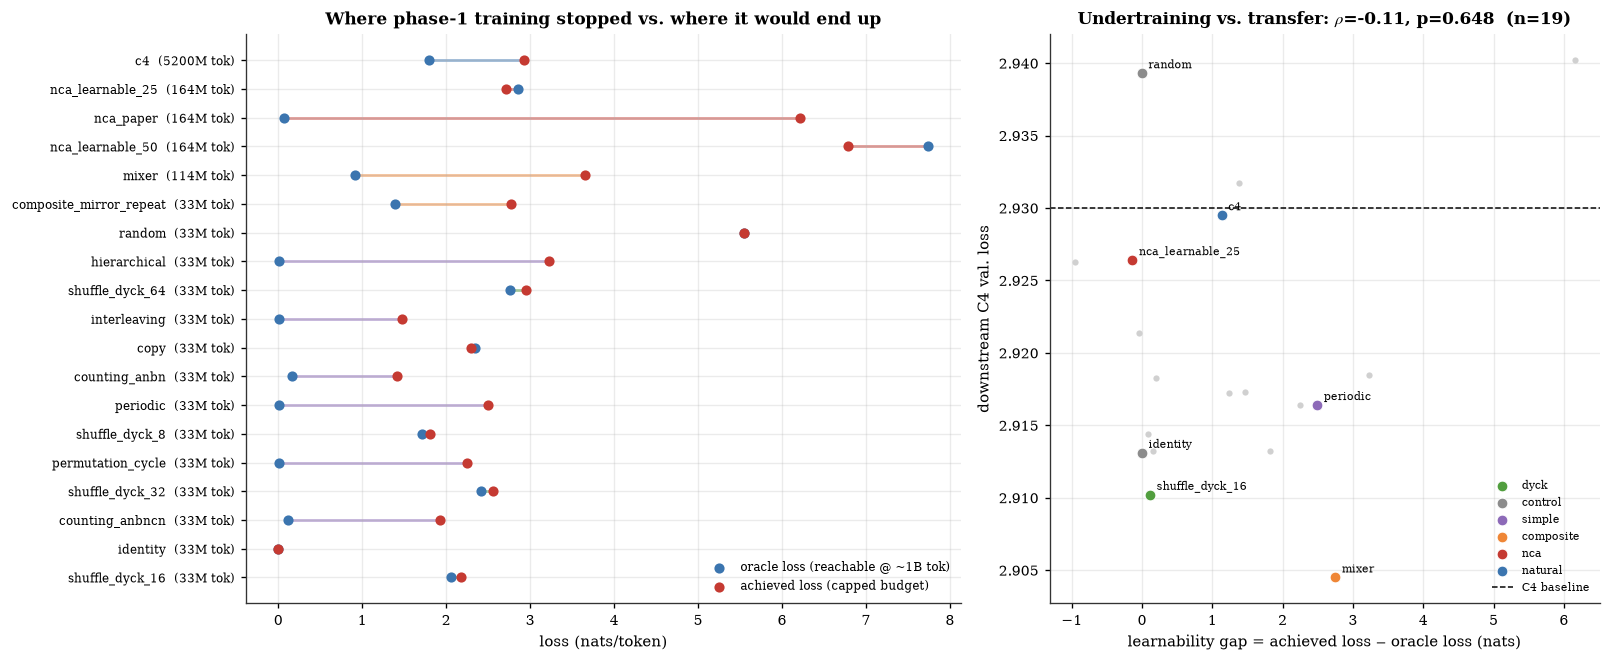

In [ ]:
def spearman_perm(x, y, n_perm=20_000, seed=0):
    """Spearman rank correlation, with a p-value from permuting y (not a parametric formula)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    n = x.size
    if n < 4:
        return np.nan, np.nan, n
    rho = float(stats.spearmanr(x, y).statistic)
    xr, yr = stats.rankdata(x), stats.rankdata(y)
    rng = np.random.default_rng(seed)
    null = np.array([np.corrcoef(xr, rng.permutation(yr))[0, 1] for _ in range(n_perm)])
    p = (np.sum(np.abs(null) >= abs(rho) - 1e-12) + 1) / (n_perm + 1)
    return rho, float(p), n


def jackknife_rho(x, y):
    """Leave-one-out range of the correlation: how much does dropping a single condition move it?"""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    vals = [stats.spearmanr(np.delete(x, i), np.delete(y, i)).statistic for i in range(x.size)]
    return float(np.min(vals)), float(np.max(vals))


def bh_fdr(p):
    """Benjamini-Hochberg FDR correction, applied whenever we run many correlations at once."""
    p = np.asarray(p, dtype=float)
    ok = np.isfinite(p)
    out = np.full(p.shape, np.nan)
    q = p[ok]
    n = q.size
    order = np.argsort(q)
    adj = q[order] * n / (np.arange(n) + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    res = np.empty(n)
    res[order] = np.clip(adj, 0, 1)
    out[ok] = res
    return out


def corr_row(label, x, y, seed=0):
    """One row for a results table: Spearman rho + permutation p + jackknife range + Pearson r."""
    rho, p, n = spearman_perm(x, y, seed=seed)
    lo, hi = jackknife_rho(x, y)
    pear = stats.pearsonr(
        *[
            np.asarray(v, float)[
                np.isfinite(np.asarray(x, float)) & np.isfinite(np.asarray(y, float))
            ]
            for v in (x, y)
        ]
    )
    return {
        "pair": label,
        "n": n,
        "spearman": rho,
        "p_perm": p,
        "jk_min": lo,
        "jk_max": hi,
        "pearson": pear.statistic,
    }


gap = M.loc[
    ~M["is_baseline"], ["pre", "family", "p1_tokens", "p1_val_loss", "oracle_loss", "d_val_loss"]
].copy()
gap["p1_tokens_M"] = gap["p1_tokens"] / 1e6
gap["gap"] = gap["p1_val_loss"] - gap["oracle_loss"]
gap = gap.sort_values("p1_tokens_M").reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6), gridspec_kw={"width_ratios": [1.3, 1]})

# Panel 1: dumbbell plot, one row per condition, ordered by phase-1 token budget
ax = axes[0]
y = np.arange(len(gap))
for yi, (_, r) in zip(y, gap.iterrows(), strict=False):
    color = FAMILY_COLORS.get(r["family"], FAMILY_COLORS["other"])
    ax.plot(
        [r["oracle_loss"], r["p1_val_loss"]], [yi, yi], color=color, lw=1.6, alpha=0.55, zorder=1
    )
ax.scatter(
    gap["oracle_loss"],
    y,
    color="#3B75AF",
    s=26,
    zorder=3,
    label="oracle loss (reachable @ ~1B tok)",
)
ax.scatter(
    gap["p1_val_loss"], y, color="#C53A32", s=26, zorder=3, label="achieved loss (capped budget)"
)
ax.set_yticks(y)
ax.set_yticklabels(
    [f"{r['pre']}  ({r['p1_tokens_M']:.0f}M tok)" for _, r in gap.iterrows()], fontsize=7
)
ax.set_xlabel("loss (nats/token)")
ax.set_title("Where phase-1 training stopped vs. where it would end up")
ax.legend(fontsize=7, frameon=False, loc="lower right")

# Panel 2: does the size of the gap predict downstream transfer?
ax2 = axes[1]
scatter_with_highlights(
    ax2, gap.rename(columns={"pre": "name"}), "gap", "d_val_loss", name_col="name"
)
ax2.axhline(base["d_val_loss"], color="k", ls="--", lw=0.9, label="C4 baseline")
rho, p, n = spearman_perm(gap["gap"], gap["d_val_loss"], n_perm=5000, seed=71)
ax2.set_xlabel("learnability gap = achieved loss $-$ oracle loss (nats)")
ax2.set_ylabel("downstream C4 val. loss")
ax2.set_title(f"Undertraining vs. transfer: $\\rho$={rho:+.2f}, p={p:.3f}  (n={n})")
h2, l2 = ax2.get_legend_handles_labels()
ax2.legend(h2, l2, fontsize=6.5, frameon=False)

fig.savefig(PLOTS / "learnability_gap_sweet_spot.png", bbox_inches="tight")
plt.show()

# print(gap[["pre", "family", "p1_tokens_M", "oracle_loss", "p1_val_loss", "gap", "d_val_loss"]].to_string(index=False))
# print(f"\ngap -> downstream val loss: rho={rho:+.3f}, p={p:.3f}, n={n}")

**Q0 answer: no.**

* $\rho$ = -0.11 ($p$=0.65, $n$=19) — statistically indistinguishable from zero. How undertrained a pattern is (relative to its own oracle loss) does not predict how well it transfers to C4.
* `mixer` has one of the largest gaps (2.75 nats) yet is the single best downstream condition (2.9045, ahead of the `c4` baseline at 2.9295) — a big gap clearly isn't disqualifying.
* `nca_paper` has an even larger gap (6.15 nats) and is the *worst* downstream condition (2.9402) — so a big gap is no guarantee of good transfer either.
* A few gaps are slightly negative (`identity`, `copy`, `random`, and the NCA-learnable patterns): achieved loss came in at or under the reported oracle loss. For `identity`/`copy`/`random` this is  noise around zero.

**Bottom line:** there's no simple dial where "more undertrained" or "less undertrained" makes a pattern a better warm-up. Whatever makes `mixer` special isn't captured by this one number — the sweet spot, if it exists, depends on the specific structure being taught, not on how much of the pattern's own asymptote was left unreached.


## 2. Q1 — Does gzip complexity track achievable perplexity?

gzip complexity is a one-line proxy for "how predictable is this data". In this sense, it is a very good proxy for the lowest achievable perplexity. However, actual achieved perplexity is a matter of compute and model expressivity, as we will see. 

`c4_complexity.csv` mixes two very different populations:

* **natural corpora** (c4, fineweb-edu, open-web-math, codeparrot), and
* **synthetic patterns**

So we check the correlation on the pooled set and on each population separately.


In [ ]:
synth = comp[~comp["family"].isin(["natural"])]
nat = comp[comp["family"] == "natural"]

q1 = pd.DataFrame(
    [
        corr_row("ALL: gzip vs phase-1 val loss", comp["gzip"], comp["p1_val_loss"]),
        corr_row("SYNTHETIC: gzip vs phase-1 val loss", synth["gzip"], synth["p1_val_loss"]),
        corr_row("NATURAL: gzip vs phase-1 val loss", nat["gzip"], nat["p1_val_loss"]),
        corr_row("ALL: gzip vs oracle loss", comp["gzip"], comp["oracle_loss"]),
        corr_row("ALL: gzip vs H_T", comp["gzip"], comp["p1_H"]),
        corr_row("ALL: gzip vs S_T", comp["gzip"], comp["p1_S"]),
        corr_row("ALL: gzip vs structural fraction", comp["gzip"], comp["p1_struct_frac"]),
    ]
)
q1

,pair,n,spearman,p_perm,jk_min,jk_max,pearson
0,ALL: gzip vs phase-1 val loss,22,0.5844,0.0046,0.5299,0.6896,0.6359
1,SYNTHETIC: gzip vs phase-1 val loss,18,0.6058,0.0085,0.5466,0.7083,0.6521
2,NATURAL: gzip vs phase-1 val loss,4,1.0000,0.0825,1.0000,1.0000,0.9650
3,ALL: gzip vs oracle loss,22,0.8424,0.0000,0.8210,0.9227,0.7761
4,ALL: gzip vs H_T,22,0.5844,0.0046,0.5299,0.6896,0.6359
5,ALL: gzip vs S_T,22,-0.5099,0.0171,-0.5935,-0.4364,-0.5180
6,ALL: gzip vs structural fraction,22,-0.7380,0.0004,-0.7961,-0.6987,-0.6195


**How to read this table** (and every correlation table that follow):

| Column              | Meaning                                                                                                                        |
| ------------------- | ------------------------------------------------------------------------------------------------------------------------------ |
| `pair`              | Quantities being correlated.                                                                                                   |
| `n`                 | Number of conditions with both values available.                                                                               |
| `spearman`          | Spearman rank correlation ($\rho \in [-1,1]$); the main correlation measure.                                                   |
| `p_perm`            | Permutation p-value; smaller values indicate stronger evidence the correlation is not due to chance.                           |
| `jk_min` / `jk_max` | Minimum and maximum jackknife $\rho$ after leaving out one condition at a time; a wide range suggests sensitivity to outliers. |
| `pearson`           | Pearson (linear) correlation, shown for comparison.                                                                            |

* **ALL: gzip vs phase-1 val loss** — moderate positive correlation ($\rho$≈0.58, $p$<0.01): more incompressible data is somewhat harder to fit, but gzip is far from a perfect proxy in this undertrained regime.
* **SYNTHETIC: gzip vs phase-1 val loss** — Again, this is expected. Low correlation is not surprising because the phase-1 training was deliberately capped short of convergence, so achievable loss is not a fixed property of the pattern but also depends on how compute budget it received.
* **NATURAL: gzip vs phase-1 val loss** — looks like perfect rank agreement.
* **ALL: gzip vs oracle loss** — the strongest relationship in this table ($\rho$≈0.84, $p$<0.001): gzip tracks the difficulty of the *underlying generating rule* better than it tracks achieved loss. That gap between the two is expected once you factor in the deliberate phase-1 token cap: oracle loss is a fixed property of the rule, while achieved (phase-1 val.) loss also depends on how far was a model trained on that pattern.
* **ALL: gzip vs $H_T$** — about as loose a relationship as gzip vs. val loss ($\rho$≈0.58, $p$<0.01): gzip only partially captures residual unpredictability. But again, the deliberate phase-1 token cap is a confounder.
* **ALL: gzip vs $S_T$** — negative correlation ($\rho$≈-0.51, $p$=0.02): patterns with more learnable structure ($S_T$) tend to be *more* compressible.
* **ALL: gzip vs structural fraction** — the second-strongest relationship, and negative ($\rho$≈-0.74, $p$<0.001): a higher share of rule-like structure goes with lower gzip complexity, reinforcing the previous point. This would be more pronounced if we had trained the models longer, but the deliberate phase-1 token cap prevents a higher correlation from emerging.

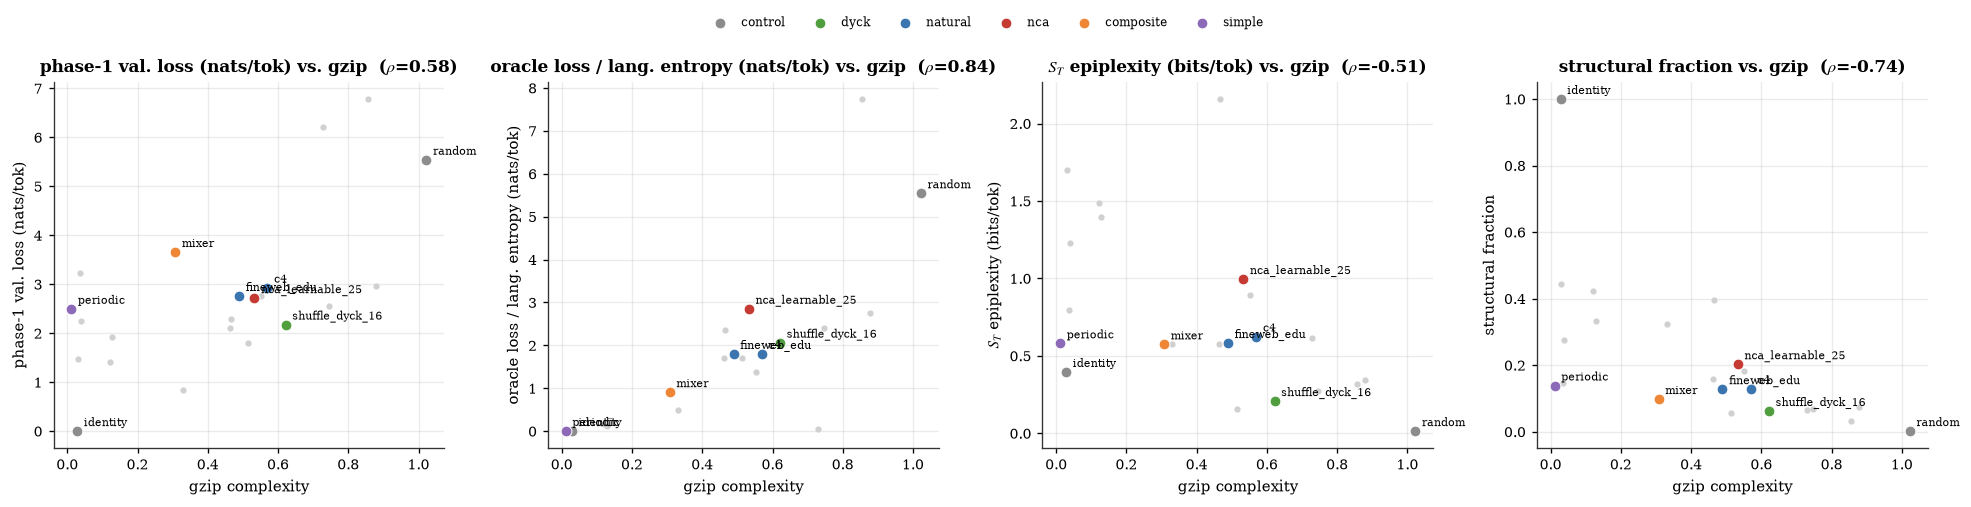

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16.5, 3.9))

panels = [
    ("gzip", "p1_val_loss", "gzip complexity", "phase-1 val. loss (nats/tok)"),
    ("gzip", "oracle_loss", "gzip complexity", "oracle loss / lang. entropy (nats/tok)"),
    ("gzip", "p1_S", "gzip complexity", "$S_T$ epiplexity (bits/tok)"),
    ("gzip", "p1_struct_frac", "gzip complexity", "structural fraction"),
]
for ax, (xcol, ycol, xlab, ylab) in zip(axes, panels, strict=False):
    scatter_with_highlights(ax, comp, xcol, ycol, name_col="name")
    rho = stats.spearmanr(comp[xcol], comp[ycol], nan_policy="omit").statistic
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title(f"{ylab} vs. gzip  ($\\rho$={rho:.2f})")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    fontsize=7,
    loc="upper center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, 1.08),
    frameon=False,
)
fig.savefig(PLOTS / "q1_gzip_vs_loss.png", bbox_inches="tight")
plt.show()

## 3. Q2 — Epiplexity is not a re-parameterization of gzip

gzip measures **incompressibility** of the raw bytes. $S_T$ measures something different: how much
the *model* had to learn online to predict the data well. If $S_T$ were redundant with gzip, points
would fall on a rising diagonal below. Instead, the two axes below split the corpus into four
readable groups:

* **low gzip, high $S_T$** — compressible, but the model still had to build real machinery to
  predict it (interesting: structure that a generic compressor cannot see).
* **high gzip, low $S_T$** — incompressible *and* nothing to learn (noise).
* the other two corners are the "boring" cases where gzip and $S_T$ agree.


$S_T$ is measured *within* the deliberately capped phase-1 budget, so it reflects how much structure the model absorbed by the time training stopped — not necessarily the pattern's full learnable content (which, given enough tokens, every pattern here can reach).

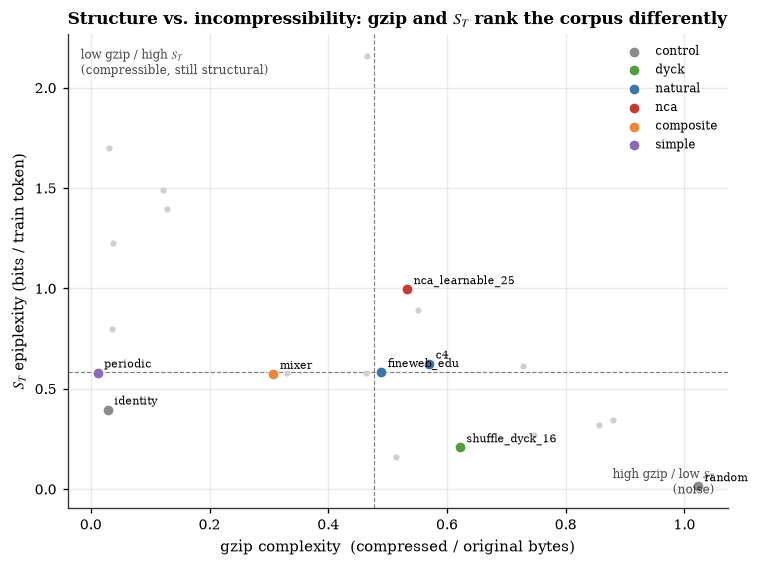

Where do the top-5 downstream (PPL impr%) patterns sit on the gzip/S_T grid?


,pre,family,ppl_impr_pct,gzip,p1_S,quadrant
0,mixer,composite,2.5100,0.3073,0.5739,low gzip / low $S_T$
1,shuffle_dyck_16,dyck,1.9600,0.6215,0.2078,high gzip / low $S_T$ (noise)
2,identity,control,1.6800,0.0283,0.3959,low gzip / low $S_T$
3,counting_anbncn,simple,1.6600,0.1280,1.3962,"low gzip / high $S_T$ (compressible, structural)"
4,shuffle_dyck_32,dyck,1.6600,0.7458,0.2706,high gzip / low $S_T$ (noise)


In [ ]:
fig, ax = plt.subplots(figsize=(6.4, 4.8))
gz_med, s_med = comp["gzip"].median(), comp["p1_S"].median()
ax.axvline(gz_med, color="k", lw=0.7, ls="--", alpha=0.5)
ax.axhline(s_med, color="k", lw=0.7, ls="--", alpha=0.5)

scatter_with_highlights(ax, comp, "gzip", "p1_S", name_col="name")

ax.set_xlabel("gzip complexity  (compressed / original bytes)")
ax.set_ylabel("$S_T$ epiplexity (bits / train token)")
ax.set_title("Structure vs. incompressibility: gzip and $S_T$ rank the corpus differently")
ax.text(
    0.02,
    0.97,
    "low gzip / high $S_T$\n(compressible, still structural)",
    transform=ax.transAxes,
    va="top",
    fontsize=7,
    alpha=0.7,
)
ax.text(
    0.98,
    0.03,
    "high gzip / low $S_T$\n(noise)",
    transform=ax.transAxes,
    ha="right",
    fontsize=7,
    alpha=0.7,
)
ax.legend(fontsize=7, frameon=False)
fig.savefig(PLOTS / "q2_st_vs_gzip_quadrant.png", bbox_inches="tight")
plt.show()


def _quadrant(gz, s):
    if gz <= gz_med and s >= s_med:
        return "low gzip / high $S_T$ (compressible, structural)"
    if gz > gz_med and s < s_med:
        return "high gzip / low $S_T$ (noise)"
    if gz <= gz_med and s < s_med:
        return "low gzip / low $S_T$"
    return "high gzip / high $S_T$"


top5 = (
    M.loc[~M["is_baseline"]]
    .nlargest(5, "ppl_impr_pct")[["pre", "family", "ppl_impr_pct"]]
    .merge(comp[["name", "gzip", "p1_S"]], left_on="pre", right_on="name", how="left")
    .drop(columns="name")
)
top5["quadrant"] = [_quadrant(gz, s) for gz, s in zip(top5["gzip"], top5["p1_S"], strict=False)]
print("Where do the top-5 downstream (PPL impr%) patterns sit on the gzip/S_T grid?")
top5[["pre", "family", "ppl_impr_pct", "gzip", "p1_S", "quadrant"]].round(4)

**In plain terms: yes.** gzip and $S_T$ are answering two different questions, and the quadrant plot above is what makes that concrete.

* **gzip asks:** "how much can a generic, off-the-shelf compressor shrink this text?" It has no idea what a Dyck bracket or a cellular-automaton rule even is — it just looks for repeated byte patterns.
* **$S_T$ asks:** "how much did *this model* actually have to learn, while training, to get good at predicting this data?" That's a much more targeted question about *learnable structure*, not just byte-level redundancy.

Those two things line up most of the time (that's the "boring" diagonal), but not always — and the interesting cases are the exceptions:

* Some patterns are **low-gzip but high-$S_T$**: a generic compressor finds them very squeezable, yet the model still had real work to do to internalize the generating rule (structure gzip can't "see" because it isn't just repetition).
* Some are **high-gzip but low-$S_T$**: they look incompressible to gzip, but the model quickly learns there's nothing more to extract — it's closer to noise dressed up as complexity.

The overall (negative) correlation between the two in Q1 confirms this isn't just plot-reading: patterns with more learnable structure tend to be *more* gzip-compressible, not less, so gzip complexity alone is not a safe stand-in for "how much a model can learn from this."

**Where do the top-5 downstream (PPL impr%) patterns sit on the gzip/S_T grid?**

| pattern         | family    |   ppl_impr_pct |   gzip |   p1_S | quadrant                                         |
|-----------------|-----------|----------------|--------|--------|--------------------------------------------------|
| mixer           | composite |           2.51 | 0.3073 | 0.5739 | low gzip / low $S_T$                             |
| shuffle_dyck_16 | dyck      |           1.96 | 0.6215 | 0.2078 | high gzip / low $S_T$ (noise)                    |
| identity        | control   |           1.68 | 0.0283 | 0.3959 | low gzip / low $S_T$                             |
| counting_anbncn | simple    |           1.66 | 0.128  | 1.3962 | low gzip / high $S_T$ (compressible, structural) |
| shuffle_dyck_32 | dyck      |           1.66 | 0.7458 | 0.2706 | high gzip / low $S_T$ (noise)                    |

In short, all over the map. The top-5 downstream patterns are not all in the same quadrant, so there is no single "sweet spot" of gzip/S_T that guarantees good transfer.

## 4. How big is the measurement noise?

Every correlation in Sections 5-7 is only meaningful relative to how noisy a single downstream number is. We have **one seed per condition**, so run-to-run variance cannot be measured directly.

Two independent yardsticks for "is this difference real, or just noise?":

1. Benchmark sampling error: how much a score would naturally jitter from run to run, just because the test set is finite (a textbook binomial stderr) — this tells us whether the *spread across all 20 conditions* is bigger than that jitter.
2. Null conditions: `c4_c4` and `identity_c4` have no real structure to transfer (they pre-pretrain on C4 itself, or on a zero-entropy pattern), so whatever downstream change they show isn't "structure transfer" — it's a rough upper bound on noise / warm-start effects, in the *same units* as the headline result.


In [ ]:
TASK_KEYS = {
    "arc_easy": ("arc_easy_acc_norm", "arc_easy_acc_norm_stderr"),
    "hellaswag": ("hellaswag_acc_norm", "hellaswag_acc_norm_stderr"),
    "lambada": ("lambada_openai_acc", "lambada_openai_acc_stderr"),
    "winogrande": ("winogrande_acc", "winogrande_acc_stderr"),
}

err_rows = []
for model in M["model"]:
    res = load_evals_yaml(model)
    if not res:
        continue
    row = {"model": model}
    for task, (_acc_k, se_k) in TASK_KEYS.items():
        row[f"{task}_se"] = res.get(se_k, np.nan)
    blimp_se = [v for k, v in res.items() if k.startswith("blimp_") and k.endswith("_acc_stderr")]
    row["blimp_se"] = (
        float(np.sqrt(np.sum(np.square(blimp_se))) / len(blimp_se)) if blimp_se else np.nan
    )
    err_rows.append(row)

SE = pd.DataFrame(err_rows)
se_mean = SE.drop(columns=["model"]).mean()

# Yardstick 1: observed spread across all 20 conditions vs. 2-sigma sampling noise
noise = M[["arc_easy", "blimp", "hellaswag", "lambada", "winogrande"]].agg(["min", "max"]).T
noise["observed_range_pp"] = (noise["max"] - noise["min"]) * 100
noise["noise_2sigma_pp"] = [se_mean[f"{t}_se"] * 2 * 100 for t in noise.index]
noise["signal_over_noise"] = noise["observed_range_pp"] / noise["noise_2sigma_pp"]
noise["verdict"] = np.where(noise["signal_over_noise"] > 1, "real spread", "could be noise")

# Yardstick 2: null conditions as an upper bound on "just noise / warm-start" for
# downstream val loss (the metric every later Q1-Q5 correlation is built on)
null_deltas = M.loc[
    M["model"].isin(["c4_c4", "identity_c4", "random_c4"]), ["model", "d_loss_delta"]
]
noise_floor_loss = null_deltas["d_loss_delta"].abs().max()
best_delta = float(M.loc[M["model"] == "mixer_c4", "d_loss_delta"].iloc[0])
identity_rank = int(M.index[M["model"] == "identity_c4"][0]) + 1

print("=== Is the signal bigger than the noise? ===\n")
print("Benchmark accuracy: observed spread across all 20 conditions vs. 2-sigma sampling noise")
display(noise[["observed_range_pp", "noise_2sigma_pp", "signal_over_noise", "verdict"]].round(3))

=== Is the signal bigger than the noise? ===

Benchmark accuracy: observed spread across all 20 conditions vs. 2-sigma sampling noise


,observed_range_pp,noise_2sigma_pp,signal_over_noise,verdict
arc_easy,1.3000,2.0180,0.6440,could be noise
blimp,1.5100,0.2640,5.7250,real spread
hellaswag,1.8200,0.9610,1.8940,real spread
lambada,3.0900,1.2930,2.3890,real spread
winogrande,3.8700,2.8090,1.3780,real spread


Four of the five benchmarks clear the noise floor, but by very different margins — and one doesn't clear it at all.

* **`arc_easy`** — signal/noise = 0.64, **could be noise**. The 1.3pp spread across all 20 conditions is actually *smaller* than 2-sigma of sampling error alone. Any `arc_easy` differences quoted between conditions later on should not be trusted.
* **`blimp`** — signal/noise = 5.73, the cleanest signal by far. BLiMP averages over many sub-tasks, which shrinks its sampling stderr much more than the other benchmarks, so even a modest 1.5pp spread is solidly above noise.
* **`lambada`** (2.39) and **`hellaswag`** (1.89) — comfortably real, roughly 2-3x their noise floor.
* **`winogrande`** — signal/noise = 1.38, real but the weakest of the four "real" benchmarks; treat differences here as suggestive rather than decisive.

**Takeaway:** when Sections 5-7 report a benchmark-composite or per-benchmark correlation, weight `blimp` most heavily, treat `hellaswag`/`lambada`/`winogrande` as supporting evidence, and discount `arc_easy` — its observed spread is consistent with pure sampling noise.


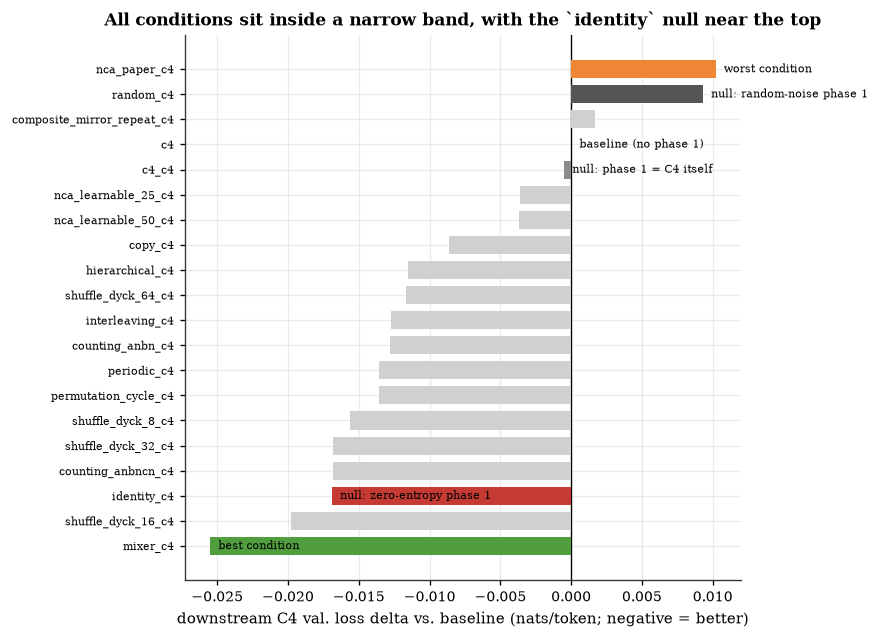

In [ ]:
fig, ax = plt.subplots(figsize=(7.4, 5.4))
d = M.sort_values("d_loss_delta")

special = {
    "c4": ("baseline (no phase 1)", "#3B75AF"),
    "c4_c4": ("null: phase 1 = C4 itself", "#8C8C8C"),
    "identity_c4": ("null: zero-entropy phase 1", "#C53A32"),
    "random_c4": ("null: random-noise phase 1", "#555555"),
}
best_m, worst_m = d.iloc[0]["model"], d.iloc[-1]["model"]
special.setdefault(best_m, ("best condition", "#519E3E"))
special.setdefault(worst_m, ("worst condition", "#EF8636"))
bar_colors = [special.get(m, ("", "#D0D0D0"))[1] for m in d["model"]]

ax.barh(d["model"], d["d_loss_delta"], color=bar_colors, height=0.72, zorder=3)
ax.axvline(0, color="k", lw=0.8)
for m, (lab, _) in special.items():
    row = d.loc[d["model"] == m]
    if len(row):
        y = d["model"].tolist().index(m)
        ax.annotate(
            lab,
            (row["d_loss_delta"].iloc[0], y),
            fontsize=6.5,
            xytext=(5, 0),
            textcoords="offset points",
            va="center",
        )
ax.set_yticks(range(len(d)))
ax.set_yticklabels(d["model"], fontsize=6.5)
ax.set_xlabel("downstream C4 val. loss delta vs. baseline (nats/token; negative = better)")
ax.set_title("All conditions sit inside a narrow band, with the `identity` null near the top")
fig.savefig(PLOTS / "q6_delta_bars.png", bbox_inches="tight")
plt.show()

## 5. Q3 — Does any phase-1 property predict downstream transfer?

This is the central question of the analysis: **can we predict, ahead of time, which synthetic pattern will help most** just from its phase-1 measurements? For each phase-1 metric we correlate against seven downstream outcomes: C4 val. loss (primary), PPL improvement %, and each of the five benchmarks individually (ARC-Easy, BLiMP, HellaSwag, LAMBADA, Winogrande). All p-values are permutation-based and corrected for testing many metrics at once (Benjamini-Hochberg FDR); the jackknife range shows how much a single condition drives each correlation, which matters with only ~19 data points.


> **Important:** Keep the deliberate phase-1 token cap in mind here too: a null result below means this particular phase-1 metric, *measured at the capped budget*, doesn't predict transfer — not that the underlying pattern property is irrelevant in some absolute sense.

In [ ]:
P1_METRICS = {
    "gzip": "gzip complexity",
    "p1_S": "$S_T$ epiplexity",
    "p1_H": "$H_T$ entropy",
    "p1_total": "$S_T + H_T$",
    "p1_struct_frac": "structural fraction",
    "p1_val_loss": "phase-1 val loss",
    "oracle_loss": "oracle loss",
    "p1_tokens": "phase-1 token budget",
}
OUTCOMES = {
    "d_val_loss": "downstream val loss",
    "ppl_impr_pct": "PPL impr %",
    "arc_easy": "ARC-Easy",
    "blimp": "BLiMP",
    "hellaswag": "HellaSwag",
    "lambada": "LAMBADA",
    "winogrande": "Winogrande",
}

X = M.loc[~M["is_baseline"]].copy()  # 19 pre-pretrained conditions; baseline has no phase 1
recs = []
seed = 0
for mk, ml in P1_METRICS.items():
    for ok, ol in OUTCOMES.items():
        seed += 1
        r = corr_row(f"{ml} -> {ol}", X[mk], X[ok], seed=seed)
        r["metric"], r["outcome"] = mk, ok
        recs.append(r)

C = pd.DataFrame(recs)
C["q_bh"] = bh_fdr(C["p_perm"])
C.sort_values("p_perm")[["pair", "n", "spearman", "jk_min", "jk_max", "p_perm", "q_bh"]]

,pair,n,spearman,jk_min,jk_max,p_perm,q_bh
21,$S_T + H_T$ -> downstream val loss,19,0.6514,0.6002,0.8440,0.0032,0.0938
22,$S_T + H_T$ -> PPL impr %,19,-0.6514,-0.8440,-0.6002,0.0033,0.0938
35,phase-1 val loss -> downstream val loss,19,0.5610,0.4938,0.7376,0.0126,0.1349
14,$H_T$ entropy -> downstream val loss,19,0.5610,0.4938,0.7376,0.0139,0.1349
15,$H_T$ entropy -> PPL impr %,19,-0.5610,-0.7376,-0.4938,0.0142,0.1349
36,phase-1 val loss -> PPL impr %,19,-0.5610,-0.7376,-0.4938,0.0144,0.1349
45,oracle loss -> BLiMP,19,-0.5224,-0.6157,-0.4680,0.0211,0.1692
25,$S_T + H_T$ -> HellaSwag,19,-0.4579,-0.6223,-0.3767,0.0483,0.3384
4,gzip complexity -> HellaSwag,19,-0.4474,-0.5397,-0.3684,0.0573,0.3467
53,phase-1 token budget -> HellaSwag,19,-0.4222,-0.5989,-0.2916,0.0716,0.3467


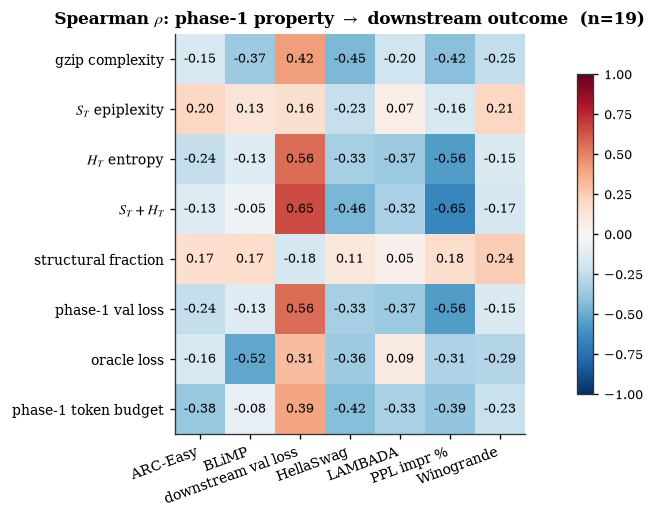

In [ ]:
pivot = C.pivot(index="metric", columns="outcome", values="spearman").loc[list(P1_METRICS)]
pivot.index = [P1_METRICS[i] for i in pivot.index]
pivot.columns = [OUTCOMES[c] for c in pivot.columns]

fig, ax = plt.subplots(figsize=(9.0, 4.4))
im = ax.imshow(pivot.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(pivot.shape[1]), pivot.columns, rotation=20, ha="right")
ax.set_yticks(range(pivot.shape[0]), pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center", fontsize=7.5)
ax.set_title("Spearman $\\rho$: phase-1 property $\\to$ downstream outcome  (n=19)")
ax.grid(False)
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.ax.tick_params(labelsize=7.5)
fig.savefig(PLOTS / "q3_corr_heatmap.png", bbox_inches="tight")
plt.show()

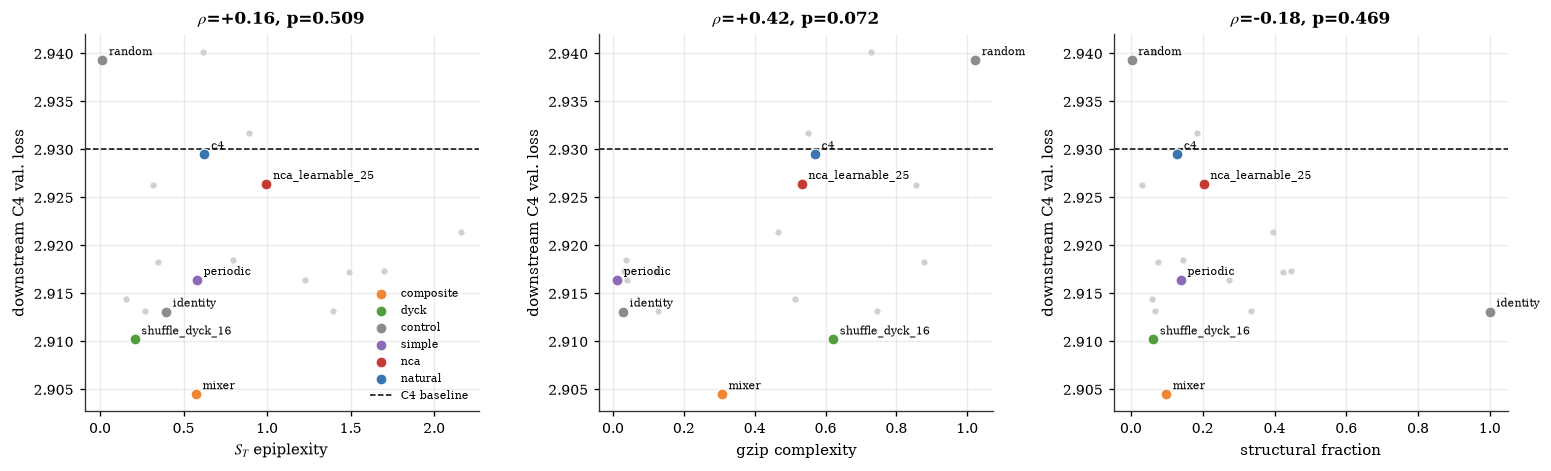

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.0))
for ax, mk in zip(axes, ["p1_S", "gzip", "p1_struct_frac"], strict=False):
    scatter_with_highlights(ax, X, mk, "d_val_loss", name_col="pre")
    ax.axhline(
        base["d_val_loss"],
        color="k",
        ls="--",
        lw=0.9,
        label="C4 baseline" if mk == "p1_S" else None,
    )
    rho, p, n = spearman_perm(X[mk], X["d_val_loss"], n_perm=5000, seed=7)
    ax.set_xlabel(P1_METRICS[mk])
    ax.set_ylabel("downstream C4 val. loss")
    ax.set_title(f"$\\rho$={rho:+.2f}, p={p:.3f}")
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, fontsize=6.5, frameon=False)
fig.savefig(PLOTS / "q3_scatter_phase1_vs_downstream.png", bbox_inches="tight")
plt.show()

**Q3 answer: no single phase-1 metric survives multiple-testing correction — but a consistent pattern still emerges.**

* **Nothing clears q<0.05.** Across all 56 tests (8 phase-1 metrics × 7 outcomes) the smallest FDR-corrected q-value is 0.09 ($S_T+H_T$ → downstream val loss). At n=19, none of these correlations should be reported as a confirmed discovery — everything below is "suggestive," not "proven."
* **The strongest raw signal is total epiplexity ($S_T+H_T$) → downstream val loss** (ρ=+0.65, p=0.003, q=0.09), mirrored by an equally strong (and opposite-signed) link to PPL improvement %. $H_T$ entropy alone and phase-1 val loss both give the identical ρ=+0.56 — unsurprising, since at this token budget "how much uncertainty is left" and "how well the model actually fit the pattern" are closely related readings of the same underlying quantity.
* **The most credible *individual benchmark* result is oracle loss → BLiMP** (ρ=-0.52, p=0.021, q=0.17): patterns with a harder underlying generating rule (higher oracle loss) tend to transfer somewhat worse to BLiMP specifically. This is worth weighting more than other one-off benchmark correlations because BLiMP is the one benchmark we already confirmed clears the sampling-noise floor by a wide margin.
* **ARC-Easy correlates weakly with everything** (|ρ|≤0.24, every p>0.3). This is a useful sanity check: the noisiest benchmark is also the one that shows the least (and least consistent) relationship to any phase-1 property.
* **gzip complexity** points the "right" direction everywhere (positive with val loss, negative with every benchmark) but never reaches significance on its own (best: p=0.07 for val loss).
* **Structural fraction is the weakest predictor across the board** — near-zero with every outcome (|ρ|≤0.24) and the only metric that fails to reach even p<0.1 anywhere.

**Bottom line:** with 19 conditions and 5 (correlated) benchmarks plus 2 loss-derived outcomes, no result here survives correction for multiple testing. The most consistent (if unconfirmed) story is that phase-1 $H_T$/$S_T+H_T$/val-loss-type metrics track downstream val loss and PPL improvement better than any single benchmark does, and that BLiMP — the one benchmark whose signal we trust — shows a plausible link to oracle loss. Everything else, should be treated as noise until more seeds are run.

## 6. Q4 — The complexity-matching hypothesis

Lee et al. (2026) claim transfer is maximized when the synthetic source *matches the complexity of
the target domain*. Concretely: the closer a pattern's phase-1 statistics are to C4's own phase-1
statistics, the better it should transfer to a C4 target. We test three notions of "distance to
C4" — gzip distance, $S_T$ distance, and loss distance — each measured against the `c4` row in
`comp` as the reference point. Under the hypothesis, all three should correlate **positively** with
downstream val. loss (closer to C4 → lower/better loss).


In [ ]:
ref = comp.loc[comp["name"] == "c4"].iloc[0]
X = X.assign(
    d_gzip=(X["gzip"] - ref["gzip"]).abs(),
    d_S=(X["p1_S"] - ref["p1_S"]).abs(),
    d_H=(X["p1_H"] - ref["p1_H"]).abs(),
    d_loss=(X["p1_val_loss"] - ref["p1_val_loss"]).abs(),
)

match = pd.DataFrame(
    [
        corr_row("|gzip - gzip_C4| -> downstream val loss", X["d_gzip"], X["d_val_loss"], seed=11),
        corr_row("|S_T - S_T(C4)| -> downstream val loss", X["d_S"], X["d_val_loss"], seed=12),
        corr_row("|H_T - H_T(C4)| -> downstream val loss", X["d_H"], X["d_val_loss"], seed=13),
        corr_row("|loss - loss_C4| -> downstream val loss", X["d_loss"], X["d_val_loss"], seed=14),
        corr_row("|gzip - gzip_C4| -> BLiMP", X["d_gzip"], X["blimp"], seed=15),
        corr_row("|S_T - S_T(C4)| -> BLiMP", X["d_S"], X["blimp"], seed=16),
    ]
)
match["q_bh"] = bh_fdr(match["p_perm"])
match

,pair,n,spearman,p_perm,jk_min,jk_max,pearson,q_bh
0,|gzip - gzip_C4| -> downstream val loss,19,-0.2739,0.2556,-0.3957,-0.1849,-0.2393,0.8378
1,|S_T - S_T(C4)| -> downstream val loss,19,-0.1220,0.6179,-0.2386,0.0269,-0.1007,0.8378
2,|H_T - H_T(C4)| -> downstream val loss,19,-0.0948,0.6979,-0.2779,-0.0052,0.3450,0.8378
3,|loss - loss_C4| -> downstream val loss,19,-0.0948,0.6982,-0.2779,-0.0052,0.3450,0.8378
4,|gzip - gzip_C4| -> BLiMP,19,0.0228,0.9253,-0.0898,0.0940,-0.0046,0.9253
5,|S_T - S_T(C4)| -> BLiMP,19,-0.1536,0.5342,-0.2891,-0.0475,-0.0787,0.8378


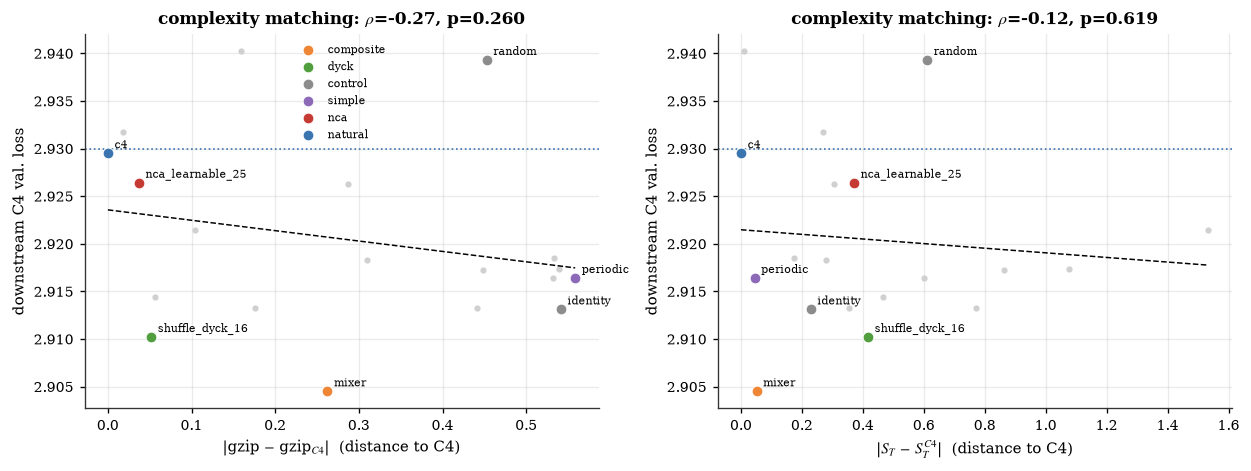

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
for ax, (k, lab) in zip(
    axes, [("d_gzip", "|gzip $-$ gzip$_{C4}$|"), ("d_S", "|$S_T$ $-$ $S_T^{C4}$|")], strict=False
):
    scatter_with_highlights(ax, X, k, "d_val_loss", name_col="pre")
    b, a = np.polyfit(X[k], X["d_val_loss"], 1)
    xs = np.linspace(X[k].min(), X[k].max(), 20)
    ax.plot(xs, b * xs + a, color="k", lw=0.9, ls="--", zorder=2)
    ax.axhline(base["d_val_loss"], color="#3B75AF", ls=":", lw=1.0)
    rho, p, _ = spearman_perm(X[k], X["d_val_loss"], n_perm=5000, seed=21)
    ax.set_xlabel(f"{lab}  (distance to C4)")
    ax.set_ylabel("downstream C4 val. loss")
    ax.set_title(f"complexity matching: $\\rho$={rho:+.2f}, p={p:.3f}")
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, fontsize=6.5, frameon=False)
fig.savefig(PLOTS / "q4_complexity_matching.png", bbox_inches="tight")
plt.show()

**Q4 answer: no — if anything, the data points the opposite way from the complexity-matching hypothesis, though not significantly.**

* **Nothing survives correction.** All six tests land at q_bh≥0.84 — none of the "distance to C4" measures predict downstream val loss or BLiMP at any reliable level (every p_perm ≥ 0.26).
* **Every distance-to-val-loss correlation is negative** (gzip: ρ=-0.27, $S_T$: ρ=-0.12, $H_T$: ρ=-0.09, loss: ρ=-0.09): patterns whose phase-1 statistics are *further* from C4's own tend to have slightly *lower* (better) downstream val loss, not higher — the opposite direction the complexity-matching hypothesis predicts. The strongest of these (gzip distance) is still weak and not significant (p=0.26), so this isn't "complexity matching backfires," just that this data gives the hypothesis no support in either direction.
* **$|H_T-H_T^{C4}|$ and $|\text{loss}-\text{loss}^{C4}|$ produce nearly identical statistics** (ρ=-0.095 for both, same jackknife range, same Pearson r) — a sign that phase-1 $H_T$ and phase-1 val. loss move together almost in lockstep across these 19 conditions. Treat these two rows as one piece of evidence, not two independent checks.
* **Distance → BLiMP is essentially flat noise.** Gzip distance gives ρ=+0.02 (p=0.93, about as close to zero as a correlation gets), and $S_T$ distance gives ρ=-0.15 (p=0.53). Both flip or wash out relative to their (already weak) val-loss counterparts, and both are the least significant rows in the whole table.

**Bottom line:** the complexity-matching hypothesis (match phase-1 statistics to the target domain for better transfer) finds no support here — every correlation is weak and non-significant, and where there's any hint of a direction it runs opposite to what the hypothesis predicts rather than confirming it.

## 7. Q5 — Is phase-1 structural information conserved into phase 2?

If pre-pretraining installed reusable circuits, phase 2 should have *less structure left to re-derive*: high phase-1 $S_T$ should predict a **lower** phase-2 $S_T$ (the model already brought some structure with it), while still reaching an equal-or-lower final loss. This is the strongest version of the transfer claim we can test.


One caveat: phase-1 $S_T$ here reflects only the structure absorbed *within the capped budget*, so a weak conservation signal is ambiguous between "structure isn't reused" and "phase 1 hadn't absorbed much of it yet at that budget" — the two aren't distinguishable from this data alone.  However, we do know, from early experiments, that if we train on too much pre-pretraining data, this actually hurts downstream performance, something that the papers in the literature also agree with ([source1](https://arxiv.org/html/2603.10055v1), [source2](https://arxiv.org/html/2502.19249v2)).

In [ ]:
cons = pd.DataFrame(
    [
        corr_row("phase-1 $S_T$ -> phase-2 $S_T$", X["p1_S"], X["p2_S"], seed=31),
        corr_row("phase-2 $S_T$ -> downstream val loss", X["p2_S"], X["d_val_loss"], seed=32),
        corr_row(
            "phase-2 initial loss -> downstream val loss",
            X["p2_init_loss"],
            X["d_val_loss"],
            seed=33,
        ),
        corr_row("phase-1 $S_T$ -> phase-2 initial loss", X["p1_S"], X["p2_init_loss"], seed=34),
    ]
)
cons["q_bh"] = bh_fdr(cons["p_perm"])
cons

,pair,n,spearman,p_perm,jk_min,jk_max,pearson,q_bh
0,phase-1 $S_T$ -> phase-2 $S_T$,19,-0.0825,0.7363,-0.1517,0.0609,0.0135,0.9712
1,phase-2 $S_T$ -> downstream val loss,19,0.1352,0.5738,-0.0176,0.2469,-0.0728,0.9712
2,phase-2 initial loss -> downstream val loss,19,-0.0088,0.9712,-0.1870,0.1023,-0.1860,0.9712
3,phase-1 $S_T$ -> phase-2 initial loss,19,0.0421,0.8684,-0.0279,0.1827,0.0605,0.9712


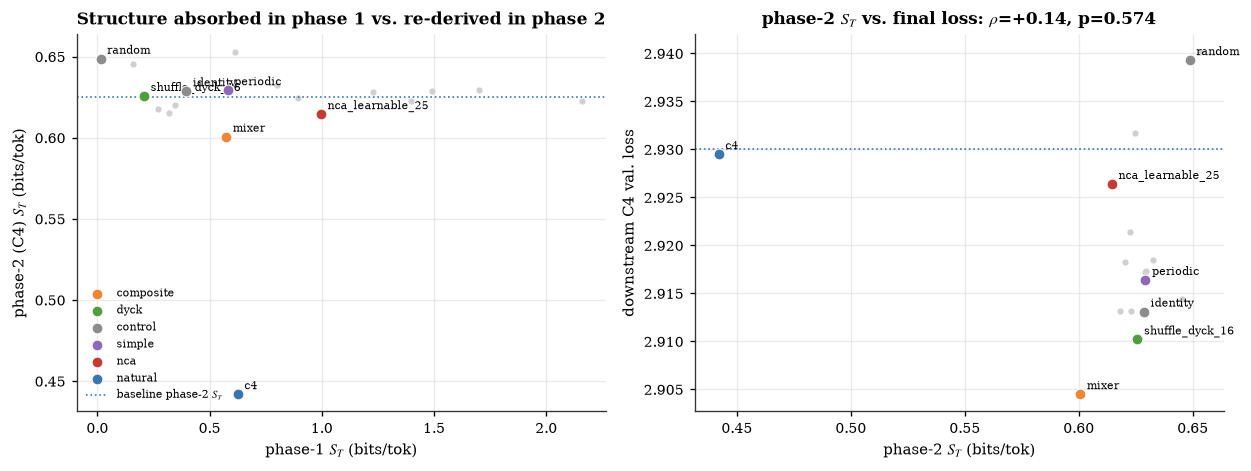

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))

scatter_with_highlights(axes[0], X, "p1_S", "p2_S", name_col="pre")
axes[0].axhline(base["p2_S"], color="#3B75AF", ls=":", lw=1.0, label="baseline phase-2 $S_T$")
axes[0].set_xlabel("phase-1 $S_T$ (bits/tok)")
axes[0].set_ylabel("phase-2 (C4) $S_T$ (bits/tok)")
axes[0].set_title("Structure absorbed in phase 1 vs. re-derived in phase 2")
h0, l0 = axes[0].get_legend_handles_labels()
axes[0].legend(h0, l0, fontsize=6.5, frameon=False)

scatter_with_highlights(axes[1], X, "p2_S", "d_val_loss", name_col="pre")
axes[1].axhline(base["d_val_loss"], color="#3B75AF", ls=":", lw=1.0)
axes[1].set_xlabel("phase-2 $S_T$ (bits/tok)")
axes[1].set_ylabel("downstream C4 val. loss")
rho, p, _ = spearman_perm(X["p2_S"], X["d_val_loss"], n_perm=5000, seed=41)
axes[1].set_title(f"phase-2 $S_T$ vs. final loss: $\\rho$={rho:+.2f}, p={p:.3f}")

fig.savefig(PLOTS / "q5_structure_conservation.png", bbox_inches="tight")
plt.show()

**Q5 answer: no — phase-1 structure is not detectably conserved into phase 2, mainly because phase-2 $S_T$ barely moves at all.**

* **All four tests are indistinguishable from zero** (|ρ|≤0.14, every p_perm≥0.57, q_bh≥0.97 across the board). Neither the "conservation" link (phase-1 $S_T$ → phase-2 $S_T$, ρ=-0.08) nor the "does it matter" link (phase-2 $S_T$ → downstream val loss, ρ=+0.14) shows any real relationship.
* **The left panel explains why: phase-2 $S_T$ is nearly constant across all 19 pre-pretrained conditions**, sitting in a narrow ~0.60-0.65 bits/tok band regardless of whether phase-1 $S_T$ was ~0.03 (`random`) or ~2.1 (the highest synthetic patterns). Whatever structure a pattern taught in phase 1, the model re-derives essentially the same amount of new structure once it hits C4 — there's no visible "discount" for having pre-pretrained on something more or less structured.
* **The one point that stands apart is the `c4` baseline itself** (phase-2 $S_T$≈0.44, well below the 0.60-0.65 band every pre-pretrained condition lands in). That's expected, not a conservation effect: `c4` has no separate phase-1 reset, so its $S_T$ reflects a single continuous run rather than a second pass over already-seen structure — it isn't really comparable to the other 19 points on this axis.
* **`mixer` again stands out on the right panel** — it has one of the higher phase-2 $S_T$ values (~0.60) *and* the best downstream val loss (2.9045), which if anything runs counter to the naive "lower phase-2 $S_T$ = more conserved = better transfer" story. `nca_learnable_25`, `identity`, `periodic`, and `shuffle_dyck_16` all cluster tightly together in both phase-2 $S_T$ (~0.61-0.63) and downstream loss (2.910-2.927), with no visible ordering that tracks their very different phase-1 $S_T$ values.

**Bottom line:** there's no evidence here that phase-1 structure is "banked" and reused in phase 2 — phase-2 $S_T$ is remarkably flat across conditions with wildly different phase-1 $S_T$, and that flat quantity has no relationship to downstream transfer either. If pre-pretraining helps, this data suggests it isn't via the mechanism of "the model has less structure left to learn."

## 8. Where in training does the difference appear?

The "speedup" numbers reported so far are aggregates over the whole phase-2 run. Loading the raw training curves lets us see **when** the pre-pretrained runs are ahead: an advantage concentrated in the first ~1k steps that then decays looks like an **optimization / warm-start** effect (a better starting point that training quickly erases); an advantage that persists or widens looks like a genuine **capability** effect.


In [ ]:
curves = {}
for model in M["model"]:
    df = load_curve(model, "training")
    if df is None or "loss" not in df:
        continue
    df = df[["step", "loss"]].dropna().sort_values("step")
    df["ema"] = df["loss"].ewm(span=200, adjust=False).mean()
    curves[model] = df

bl = curves[BASELINE].set_index("step")["ema"]
probe_steps = [200, 500, 1000, 2000, 4000, 6000, 8000, 10000]
adv_rows = []
for model, df in curves.items():
    if model == BASELINE:
        continue
    s = df.set_index("step")["ema"]
    common = s.index.intersection(bl.index)
    row = {"model": model}
    for st in probe_steps:
        near = common[common <= st]
        row[f"s{st}"] = float(s.loc[near[-1]] - bl.loc[near[-1]]) if len(near) else np.nan
    adv_rows.append(row)

ADV = pd.DataFrame(adv_rows).set_index("model")
ADV = ADV.reindex(M.set_index("model").index.drop(BASELINE))
ADV.round(4)

,s200,s500,s1000,s2000,s4000,s6000,s8000,s10000
model,,,,,,,,
mixer_c4,-0.0262,-0.1456,-0.1244,-0.0576,-0.0352,-0.0277,-0.0257,-0.0255
shuffle_dyck_16_c4,0.3173,-0.0053,-0.0692,-0.0407,-0.0264,-0.0216,-0.0203,-0.0201
identity_c4,0.1020,0.0016,-0.0167,-0.0229,-0.0212,-0.0183,-0.0171,-0.0169
counting_anbncn_c4,0.0804,-0.0026,-0.0265,-0.0297,-0.0227,-0.0188,-0.0170,-0.0167
shuffle_dyck_32_c4,0.0981,-0.0425,-0.0678,-0.0370,-0.0227,-0.0184,-0.0171,-0.0168
shuffle_dyck_8_c4,0.5351,0.1718,-0.0633,-0.0400,-0.0228,-0.0174,-0.0160,-0.0157
permutation_cycle_c4,0.1070,0.0279,-0.0048,-0.0231,-0.0186,-0.0150,-0.0136,-0.0135
periodic_c4,0.0974,0.0208,-0.0007,-0.0213,-0.0193,-0.0157,-0.0137,-0.0136
counting_anbn_c4,0.0759,0.0157,-0.0137,-0.0183,-0.0163,-0.0140,-0.0129,-0.0127


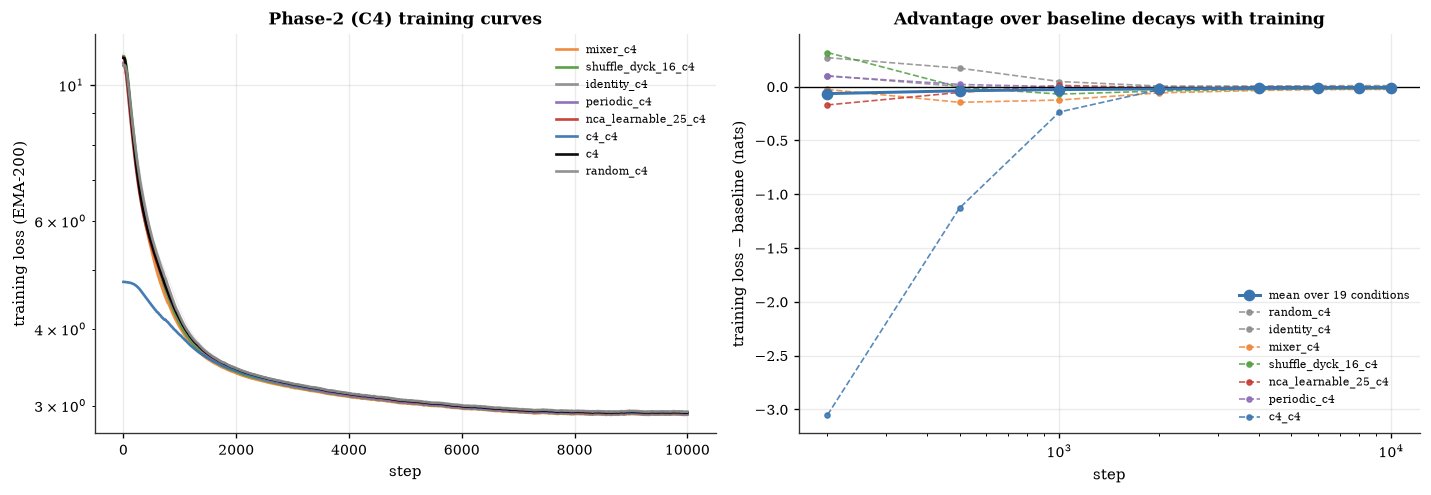

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
# Same canonical set as the rest of the notebook (as "<pattern>_c4" model names), plus the baseline.
highlight = [f"{p}_c4" for p in CANONICAL_PRE if p != "c4"] + ["c4_c4"]
highlight_color = {
    m: FAMILY_COLORS.get(FAMILY.get(m[: -len("_c4")], "other"), FAMILY_COLORS["other"])
    for m in highlight
}
highlight_color[BASELINE] = "#000000"

for model, df in curves.items():
    s = df.set_index("step")["ema"]
    is_hi = model in highlight or model == BASELINE
    lw, alpha, color = (1.6, 0.95, highlight_color.get(model)) if is_hi else (0.7, 0.35, "#D0D0D0")
    label = model if is_hi else None
    axes[0].plot(
        s.index, s.values, lw=lw, alpha=alpha, color=color, label=label, zorder=3 if is_hi else 1
    )
axes[0].set_yscale("log")
axes[0].set_xlabel("step")
axes[0].set_ylabel("training loss (EMA-200)")
axes[0].set_title("Phase-2 (C4) training curves")
axes[0].legend(fontsize=6.5, frameon=False)

mean_adv = ADV.mean(axis=0)
axes[1].plot(
    probe_steps,
    [mean_adv[f"s{s}"] for s in probe_steps],
    "o-",
    color="#3B75AF",
    lw=1.8,
    label="mean over 19 conditions",
    zorder=3,
)
for model in highlight:
    if model in ADV.index:
        axes[1].plot(
            probe_steps,
            [ADV.loc[model, f"s{s}"] for s in probe_steps],
            "o--",
            lw=1.0,
            ms=3,
            alpha=0.85,
            color=highlight_color.get(model),
            label=model,
            zorder=2,
        )
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xscale("log")
axes[1].set_xlabel("step")
axes[1].set_ylabel("training loss $-$ baseline (nats)")
axes[1].set_title("Advantage over baseline decays with training")
axes[1].legend(fontsize=6.5, frameon=False)
fig.savefig(PLOTS / "q7_curves_and_advantage.png", bbox_inches="tight")
plt.show()

In [ ]:
# Steps-to-threshold: how many steps to reach the baseline's final smoothed training loss.
target = float(bl.iloc[-1])
sp_rows = []
for model, df in curves.items():
    s = df.set_index("step")["ema"]
    hit = s.index[s.values <= target]
    step = int(hit[0]) if len(hit) else np.nan
    sp_rows.append(
        {
            "model": model,
            "steps_to_baseline_final": step,
            "speedup_x": (10000 / step) if step == step else np.nan,
        }
    )

SP = pd.DataFrame(sp_rows).merge(
    M[["model", "speedup", "d_val_loss", "p1_S", "gzip"]], on="model", how="left"
)
SP = SP.sort_values("steps_to_baseline_final")
display(SP.round(3))

,model,steps_to_baseline_final,speedup_x,speedup,d_val_loss,p1_S,gzip
0,mixer_c4,"7,023.0000",1.4240,1.4300,2.9040,0.5740,0.3070
1,shuffle_dyck_16_c4,"7,241.0000",1.3810,1.4000,2.9100,0.2080,0.6220
2,identity_c4,"7,267.0000",1.3760,1.3800,2.9130,0.3960,0.0280
3,counting_anbncn_c4,"7,267.0000",1.3760,1.3800,2.9130,1.3960,0.1280
4,shuffle_dyck_32_c4,"7,267.0000",1.3760,1.3800,2.9130,0.2710,0.7460
5,shuffle_dyck_8_c4,"7,277.0000",1.3740,1.3800,2.9140,0.1580,0.5140
7,periodic_c4,"7,624.0000",1.3120,1.3800,2.9160,0.5800,0.0110
6,permutation_cycle_c4,"7,625.0000",1.3110,1.3800,2.9160,1.2270,0.0380
8,counting_anbn_c4,"7,640.0000",1.3090,1.3700,2.9170,1.4890,0.1210
9,interleaving_c4,"7,641.0000",1.3090,1.3800,2.9170,1.7000,0.0300



sanity check against the reported Speedup column: {'pair': 'recomputed speedup vs reported speedup', 'n': 17, 'spearman': 0.951, 'p_perm': 0.0, 'jk_min': 0.941, 'jk_max': 0.973, 'pearson': np.float64(0.939)}


**Answer: almost entirely at the very start — this looks like a warm-start effect that fades by ~step 2000-4000, not a lasting capability gain.**

* **`c4_c4` is the extreme case and explains the shape of the mean curve.** At step 200 it's 3.05 nats ahead of baseline — by far the largest gap in the table — but that's a training-continuation artifact, not transfer: `c4_c4`'s phase 1 *is* C4, so at step 200 it has already seen far more C4 tokens than a model starting cold. That advantage collapses to -0.24 nats by step 1000, -0.03 by step 2000, and is gone (≈0) by step 4000 onward. Because `c4_c4` dominates the 19-condition mean early on, the "mean over 19 conditions" curve in the right panel looks like it has a large early advantage that decays — but that's mostly one condition's warm start, not a general property of pre-pretraining.
* **Every other pattern starts *behind* the baseline, not ahead.** At step 200, `mixer_c4` (-0.03) and both NCA-learnable variants (-0.27, -0.17) are the only non-`c4_c4` conditions ahead of baseline; the other 13 patterns are all positive (0.01 to 0.54 nats *worse* than baseline) at step 200. Whatever benefit pre-pretraining provides, it is not visible at initialization — it has to be earned over the first ~1000-2000 steps.
* **By step 1000-2000, nearly every condition has flipped to a small, negative (ahead-of-baseline) advantage, and from there the curves barely move.** `mixer_c4` settles at about -0.03 to -0.04 nats from step 2000 through step 10000; `shuffle_dyck_16_c4`, `identity_c4`, `counting_anbncn_c4` and most others settle into a similarly thin, stable band (roughly -0.01 to -0.02 nats) that's essentially flat from step 4000 to step 10000.
* **Two conditions do the opposite — they end up *behind* baseline and stay there.** `random_c4` and `nca_paper_c4` are the only conditions whose advantage is still positive (worse than baseline) at step 10000 (+0.0095 and +0.0102 nats respectively).
* **The steps-to-baseline ranking lines up with the downstream results.** `mixer_c4` reaches the baseline's final training loss fastest (1.43x), consistent with it being the single best downstream condition. `composite_mirror_repeat_c4` is the slowest pre-pretrained condition to get there (8,552 steps) and also has the worst downstream loss (2.932) among the conditions that do converge.

**Bottom line:** the training-curve advantage looks like an early optimization / warm-start effect, not a persisting capability gain — most of it is visible only in the first ~1-2k steps, it shrinks (rather than grows) with more training, and it settles into a small, roughly constant gap by step ~4000 that then tracks the same ordering seen in the final downstream numbers. The one large outlier (`c4_c4`) is a measurement artifact of having no separate phase-1 reset, not evidence that pre-pretraining itself produces a big early boost.
